# 03 Tree Models

This notebook is the stricter follow-up to the logistic baseline. It keeps the baseline notebook's reporting style, but upgrades the modeling side in three ways:

1. switch from a random split to a **time-based validation split**
2. add **competition-style feature engineering** inspired by the 1st-place solution
3. compare a **linear reference model** against several **tree ensembles**


In [1]:
from pathlib import Path
import importlib
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.fraud_detection.eda as eda_module
import src.fraud_detection.tree_models as tree_models_module

importlib.reload(eda_module)
importlib.reload(tree_models_module)

from src.fraud_detection.eda import PLOT_COLORS, set_plot_theme
from src.fraud_detection.tree_models import (
    build_engineered_feature_catalog,
    fit_tree_model_benchmark,
)

warnings.filterwarnings("ignore")
set_plot_theme()
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

SAMPLE_SIZE = 80_000
VALID_FRACTION = 0.20
MISSING_THRESHOLD = 0.98
RANDOM_STATE = 42


In [2]:
benchmark = fit_tree_model_benchmark(
    sample_size=SAMPLE_SIZE,
    valid_fraction=VALID_FRACTION,
    missing_threshold=MISSING_THRESHOLD,
    random_state=RANDOM_STATE,
)

comparison = benchmark["comparison"].copy()
threshold_tables = benchmark["threshold_tables"]
curve_frames = benchmark["curve_frames"]
prediction_frame = benchmark["prediction_frame"].copy()
y_valid = np.asarray(benchmark["y_valid"])
feature_audit = benchmark["feature_audit"].copy()
engineered_feature_catalog = build_engineered_feature_catalog(
    benchmark["engineered_feature_names"]
)

run_summary = pd.DataFrame(
    [
        ["sample_size", benchmark["sample_rows"]],
        ["train_rows", benchmark["train_rows"]],
        ["validation_rows", benchmark["validation_rows"]],
        ["missing_threshold", benchmark["missing_threshold"]],
        ["tree_ensemble_auc", benchmark["ensemble_roc_auc"]],
    ],
    columns=["item", "value"],
)

core_metrics = comparison[
    ["model", "family", "roc_auc", "average_precision", "precision_at_top_1pct", "recall_at_top_1pct"]
].copy()
core_metrics = core_metrics.rename(
    columns={
        "roc_auc": "ROC-AUC",
        "average_precision": "PR-AUC",
        "precision_at_top_1pct": "Precision@Top1%",
        "recall_at_top_1pct": "Recall@Top1%",
    }
)

display(run_summary.style.format({"value": "{:,.4f}"}).hide(axis="index"))
display(core_metrics.style.format({
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}",
    "Precision@Top1%": "{:.2%}",
    "Recall@Top1%": "{:.2%}",
}).hide(axis="index"))


item,value
sample_size,"80,000.0000"
train_rows,"64,000.0000"
validation_rows,"16,000.0000"
missing_threshold,0.9800
tree_ensemble_auc,0.8876


model,family,ROC-AUC,PR-AUC,Precision@Top1%,Recall@Top1%
XGBoost,tree_model,0.8916,0.4781,85.00%,23.82%
TreeEnsembleMean,ensemble,0.8876,0.4752,83.12%,23.29%
LightGBM,tree_model,0.8832,0.4779,86.25%,24.17%
CatBoost,tree_model,0.8804,0.4478,78.75%,22.07%
HistGradientBoosting,tree_model,0.8792,0.4597,85.62%,23.99%
RandomForest,tree_model,0.8671,0.4048,73.75%,20.67%
ExtraTrees,tree_model,0.8505,0.3759,74.38%,20.84%
LogisticRegression,linear_baseline,0.8289,0.3238,66.25%,18.56%


## Feature Audit


In [3]:
display(feature_audit.style.hide(axis="index"))
display(engineered_feature_catalog.style.hide(axis="index"))

stage,count,note
raw_features_before_engineering,432,all predictors after merging transaction and identity tables
engineered_features_added,14,"new columns created for time, uid-style interactions, email, and missingness"
dropped_for_high_missingness,9,columns removed because missing rate exceeded the threshold
final_features_used,437,columns actually passed into the model pipeline
raw_features_retained,423,original Kaggle features kept after filtering
engineered_features_retained,14,newly engineered features that survived filtering


feature,description
TransactionAmt_Log,log-scaled transaction amount
TransactionAmt_Cents,fractional cent pattern from transaction amount
TransactionDay,transaction day derived from TransactionDT
TransactionWeek,transaction week derived from TransactionDT
TransactionHour,transaction hour derived from TransactionDT
TransactionDayOfWeek,transaction weekday proxy from TransactionDT
uid,card + address style pseudo-client identifier
uid2,uid plus purchaser email domain
bank_type,card network and card type interaction
email_match,whether purchaser and recipient email domains match


## Model Comparison


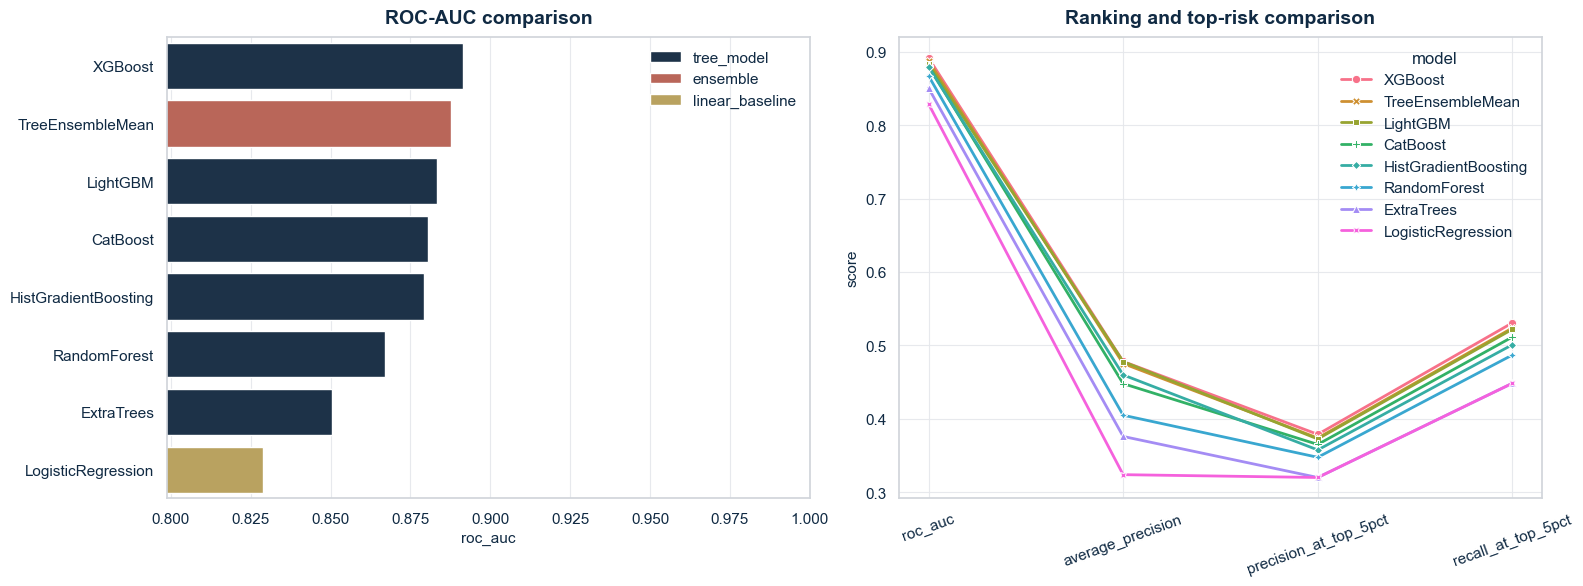

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=comparison,
    x="roc_auc",
    y="model",
    hue="family",
    dodge=False,
    palette={
        "linear_baseline": PLOT_COLORS["gold"],
        "tree_model": PLOT_COLORS["navy"],
        "ensemble": PLOT_COLORS["coral"],
    },
    ax=axes[0],
)
axes[0].set_title("ROC-AUC comparison")
axes[0].set_xlabel("roc_auc")
axes[0].set_ylabel("")
axes[0].set_xlim(max(0.5, comparison["roc_auc"].min() - 0.03), 1.0)
axes[0].legend(title="")

metric_plot = comparison.melt(
    id_vars=["model", "family"],
    value_vars=["roc_auc", "average_precision", "precision_at_top_5pct", "recall_at_top_5pct"],
    var_name="metric",
    value_name="value",
)
sns.lineplot(
    data=metric_plot,
    x="metric",
    y="value",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    linewidth=2,
    ax=axes[1],
)
axes[1].set_title("Ranking and top-risk comparison")
axes[1].set_xlabel("")
axes[1].set_ylabel("score")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## Curves


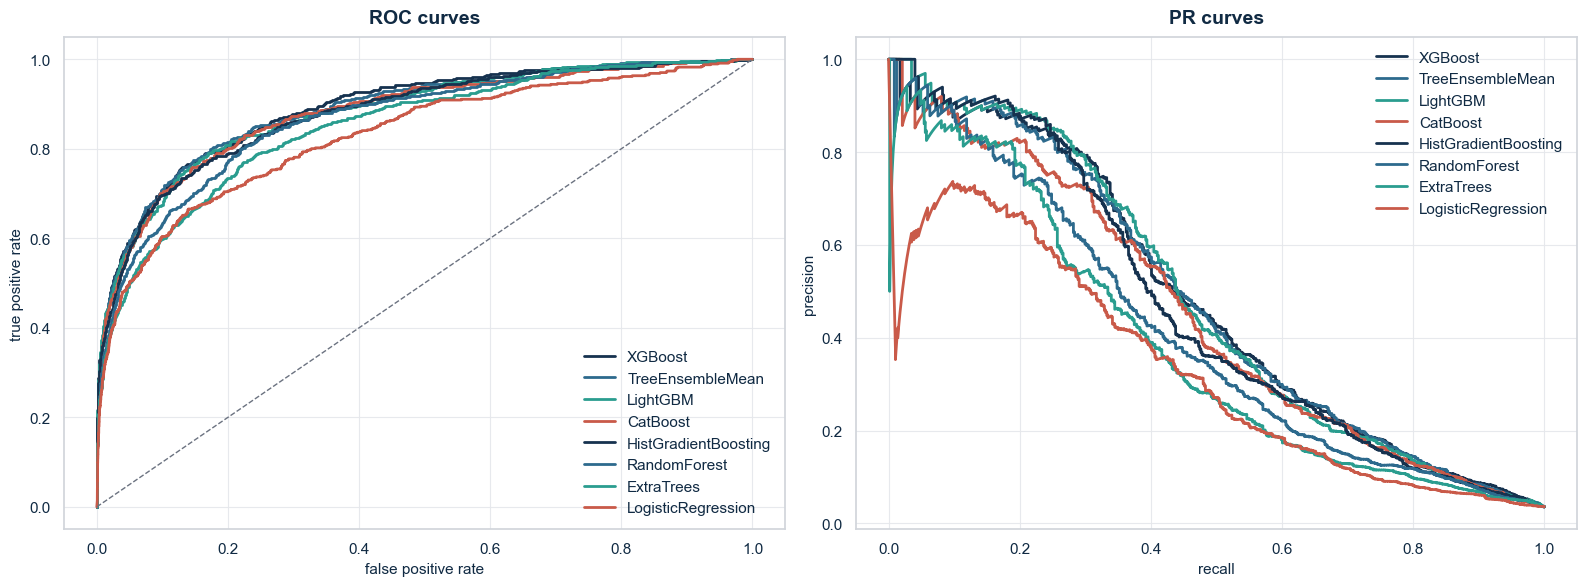

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for model_name in comparison["model"]:
    frame_pair = curve_frames[model_name]
    axes[0].plot(frame_pair["roc"]["fpr"], frame_pair["roc"]["tpr"], linewidth=2, label=model_name)
    axes[1].plot(frame_pair["pr"]["recall"], frame_pair["pr"]["precision"], linewidth=2, label=model_name)

axes[0].plot([0, 1], [0, 1], linestyle="--", color=PLOT_COLORS["muted"], linewidth=1)
axes[0].set_title("ROC curves")
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].legend()

axes[1].set_title("PR curves")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].legend()

plt.tight_layout()
plt.show()


## Threshold Sweep


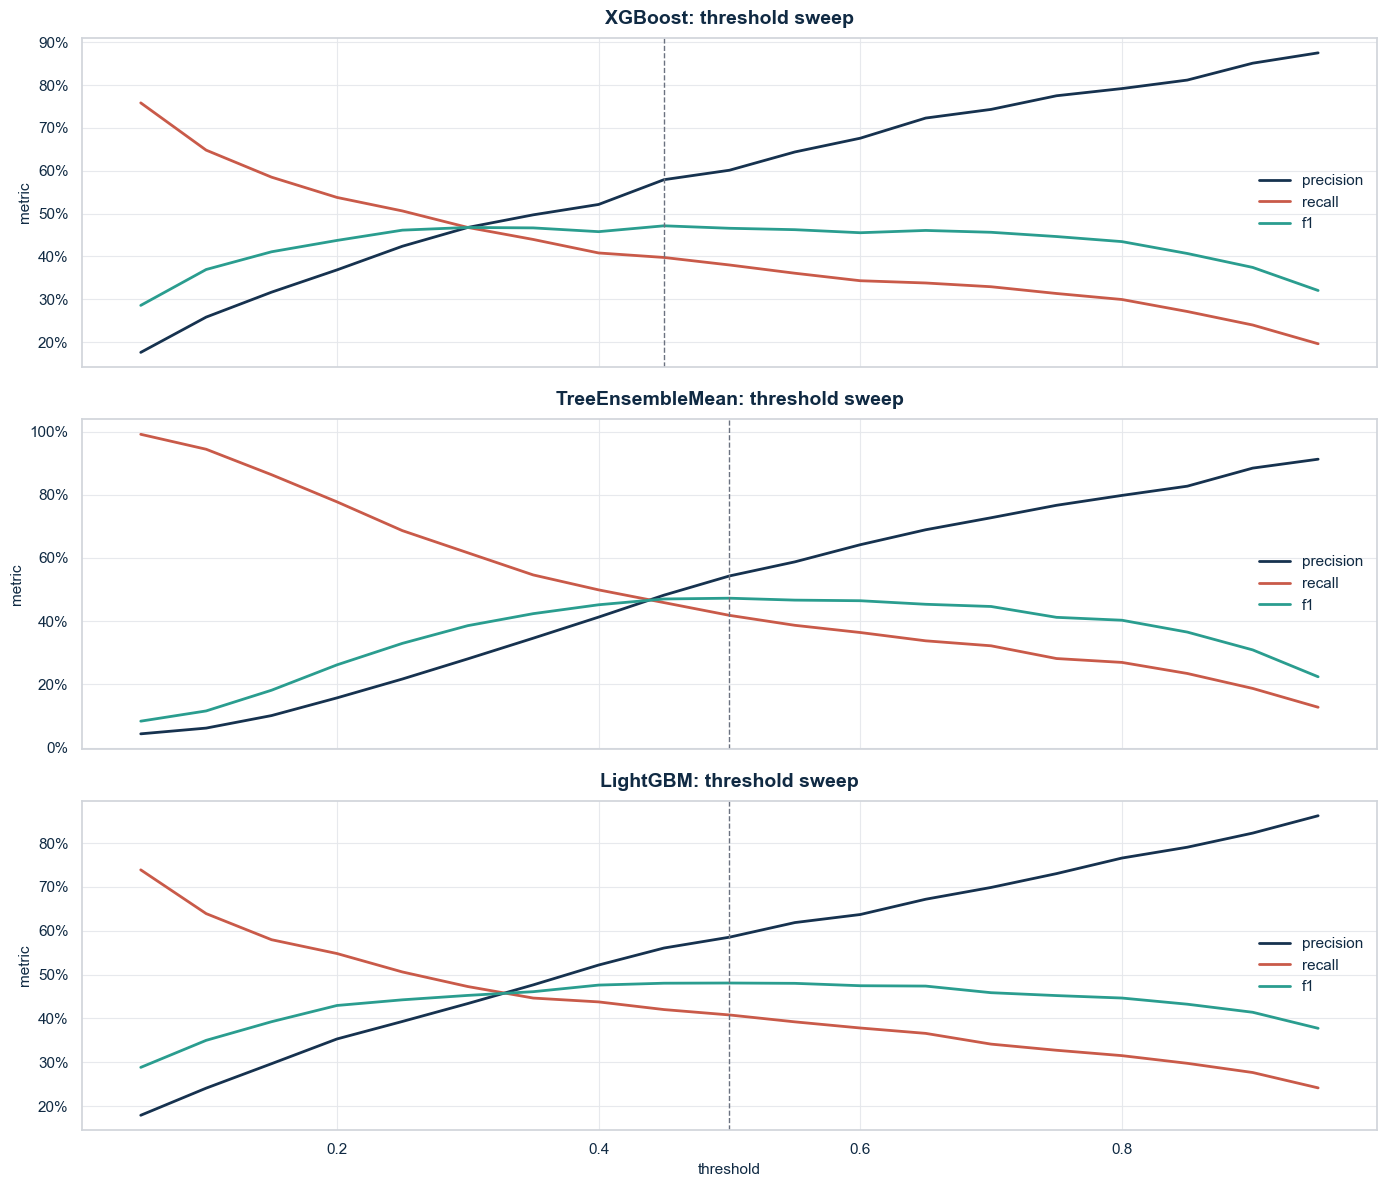

In [6]:
threshold_rows = []
for model_name in comparison["model"]:
    frame = threshold_tables[model_name].copy()
    frame["model"] = model_name
    threshold_rows.append(frame[["model", "threshold", "precision", "recall", "f1"]])

threshold_plot = pd.concat(threshold_rows, ignore_index=True)
selected_models = comparison["model"].head(min(3, len(comparison))).tolist()

fig, axes = plt.subplots(len(selected_models), 1, figsize=(14, 4 * len(selected_models)), sharex=True)
if len(selected_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, selected_models):
    model_frame = threshold_plot.loc[threshold_plot["model"] == model_name].melt(
        id_vars=["model", "threshold"],
        value_vars=["precision", "recall", "f1"],
        var_name="metric",
        value_name="value",
    )
    sns.lineplot(
        data=model_frame,
        x="threshold",
        y="value",
        hue="metric",
        palette=[PLOT_COLORS["navy"], PLOT_COLORS["coral"], PLOT_COLORS["teal"]],
        linewidth=2,
        ax=ax,
    )
    best_f1_row = threshold_tables[model_name].sort_values("f1", ascending=False).iloc[0]
    ax.axvline(best_f1_row["threshold"], linestyle="--", color=PLOT_COLORS["muted"], linewidth=1)
    ax.set_title(f"{model_name}: threshold sweep")
    ax.set_ylabel("metric")
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.legend(title="")

axes[-1].set_xlabel("threshold")
plt.tight_layout()
plt.show()


## Score Distribution


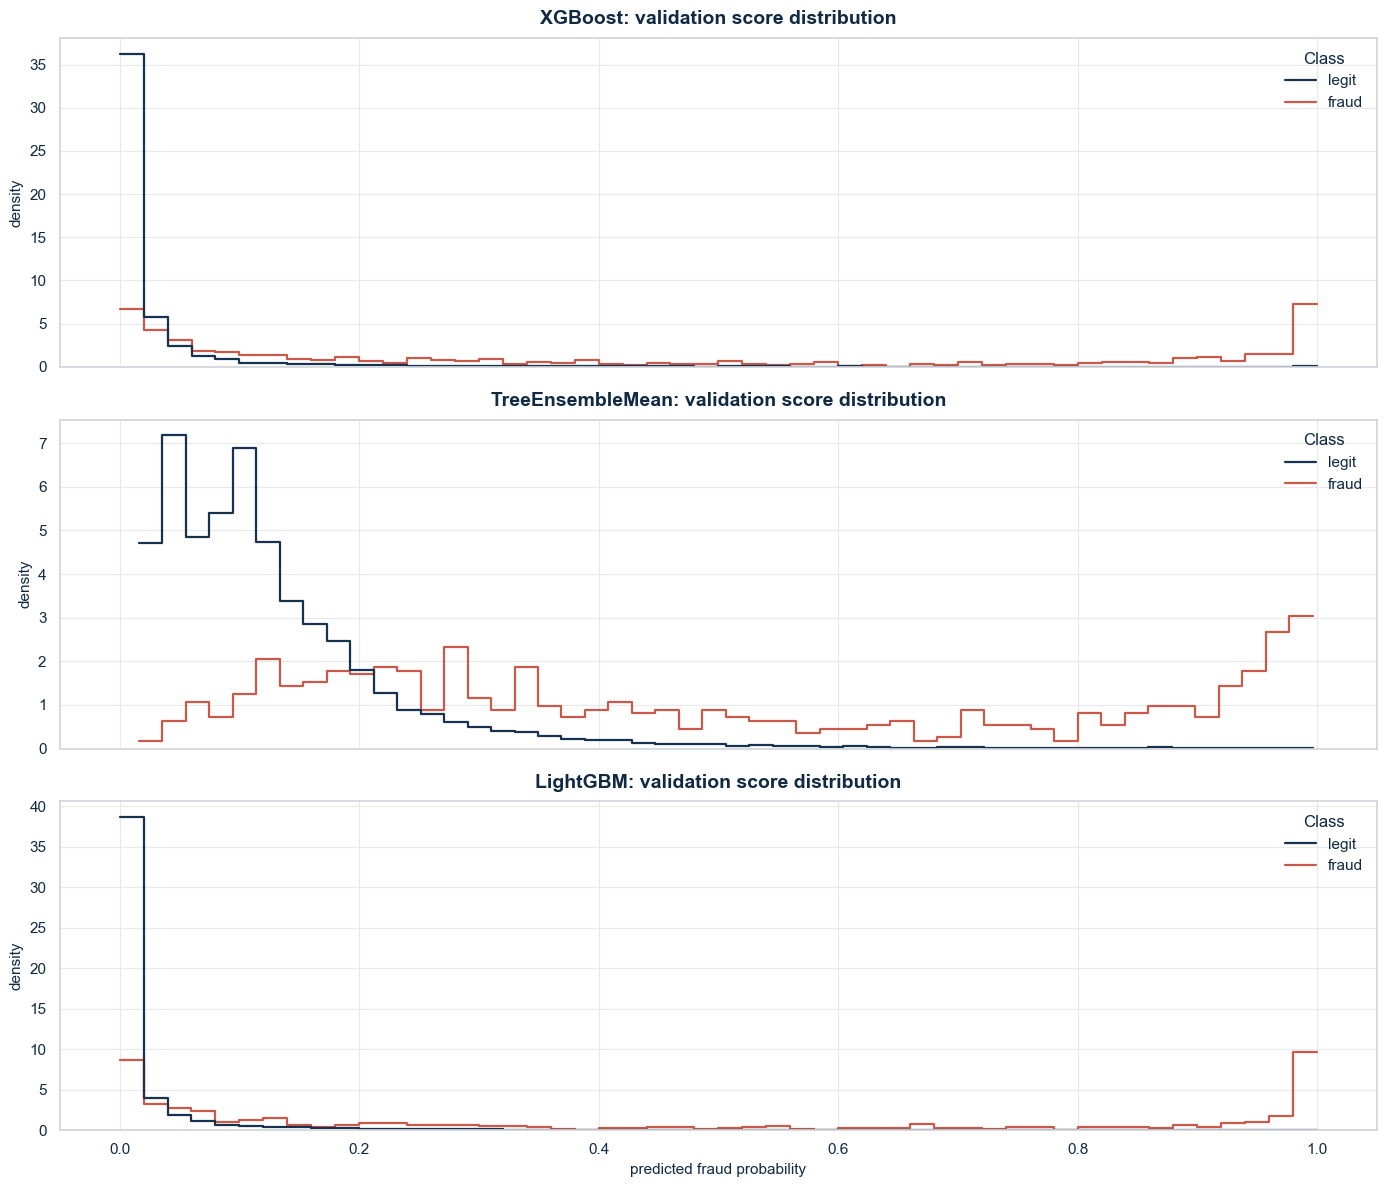

In [7]:
display_models = comparison["model"].head(min(3, len(comparison))).tolist()
fig, axes = plt.subplots(len(display_models), 1, figsize=(14, 4 * len(display_models)), sharex=True)
if len(display_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, display_models):
    score_frame = pd.DataFrame(
        {
            "score": prediction_frame[model_name],
            "Class": np.where(y_valid == 1, "fraud", "legit"),
        }
    )
    sns.histplot(
        data=score_frame,
        x="score",
        hue="Class",
        bins=50,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        linewidth=1.6,
        palette=[PLOT_COLORS["navy"], PLOT_COLORS["coral"]],
        ax=ax,
    )
    ax.set_title(f"{model_name}: validation score distribution")
    ax.set_xlabel("predicted fraud probability")
    ax.set_ylabel("density")

plt.tight_layout()
plt.show()


## Feature Importance


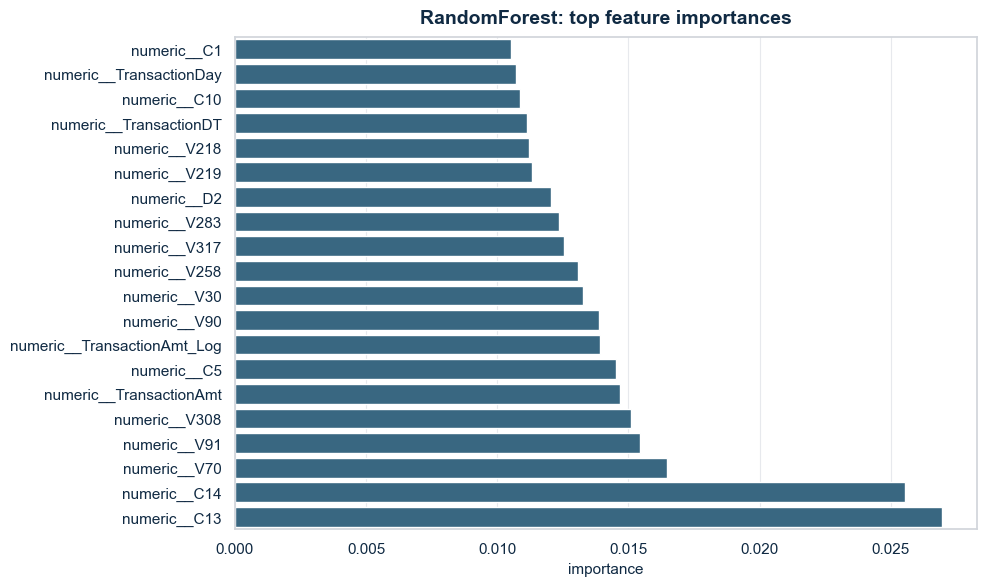

,feature,importance
0,numeric__C13,0.0269
1,numeric__C14,0.0256
2,numeric__V70,0.0165
3,numeric__V91,0.0154
4,numeric__V308,0.0151
5,numeric__TransactionAmt,0.0147
6,numeric__C5,0.0145
7,numeric__TransactionAmt_Log,0.0139
8,numeric__V90,0.0139
9,numeric__V30,0.0133


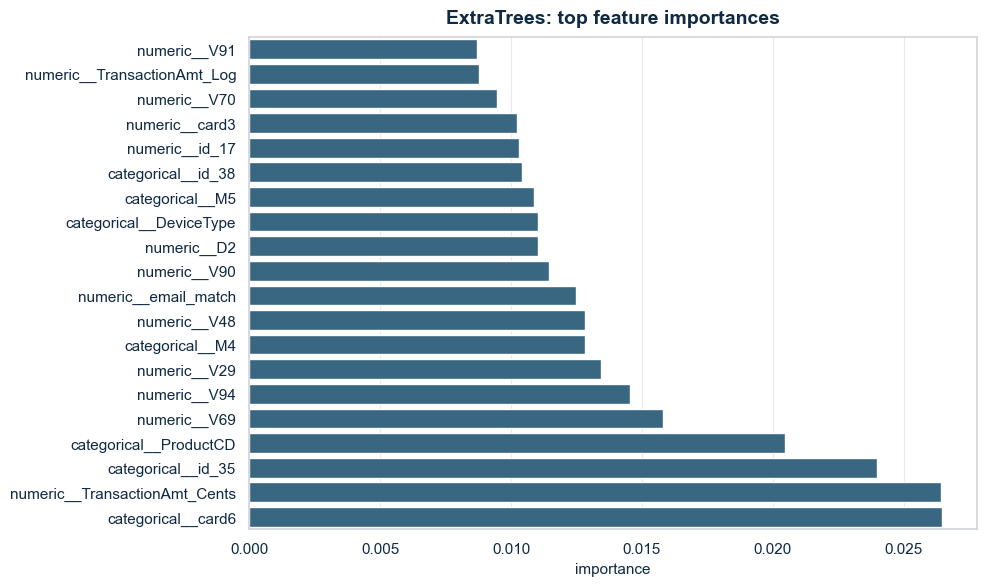

,feature,importance
0,categorical__card6,0.0265
1,numeric__TransactionAmt_Cents,0.0264
2,categorical__id_35,0.0240
3,categorical__ProductCD,0.0205
4,numeric__V69,0.0158
5,numeric__V94,0.0146
6,numeric__V29,0.0134
7,categorical__M4,0.0128
8,numeric__V48,0.0128
9,numeric__email_match,0.0125


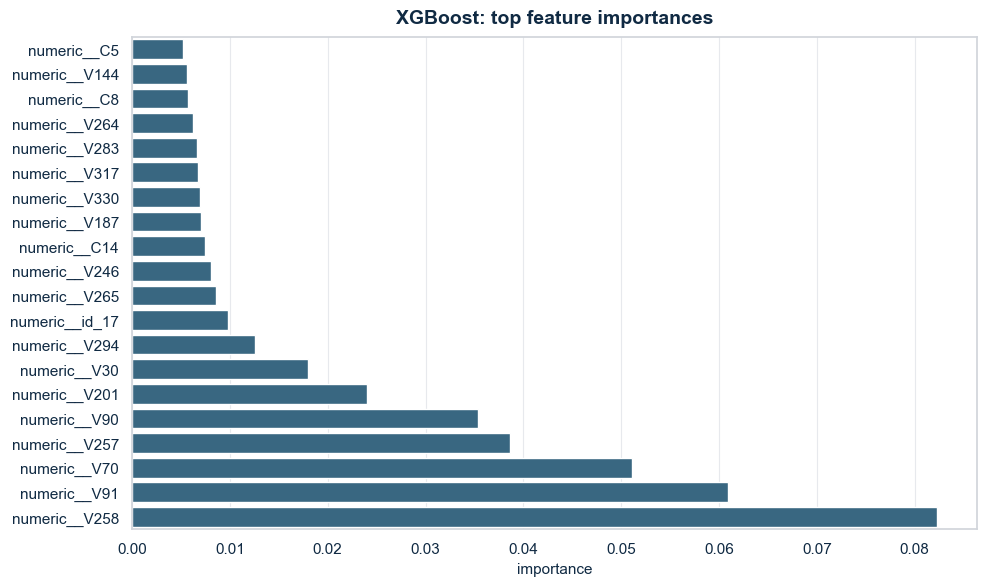

,feature,importance
0,numeric__V258,0.0823
1,numeric__V91,0.0609
2,numeric__V70,0.0511
3,numeric__V257,0.0387
4,numeric__V90,0.0353
5,numeric__V201,0.0241
6,numeric__V30,0.0180
7,numeric__V294,0.0125
8,numeric__id_17,0.0098
9,numeric__V265,0.0086


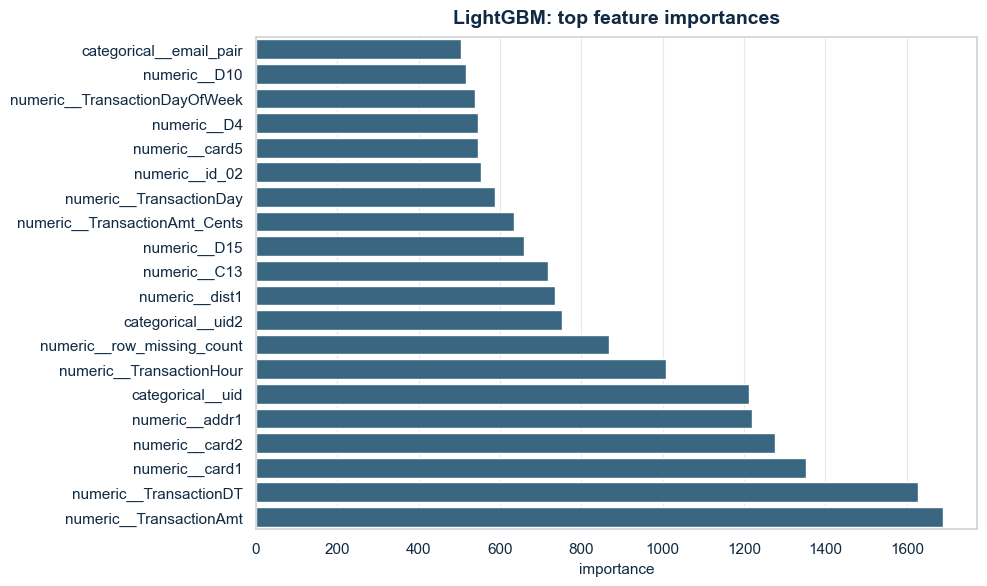

,feature,importance
0,numeric__TransactionAmt,"1,688.0000"
1,numeric__TransactionDT,"1,627.0000"
2,numeric__card1,"1,352.0000"
3,numeric__card2,"1,277.0000"
4,numeric__addr1,"1,220.0000"
5,categorical__uid,"1,213.0000"
6,numeric__TransactionHour,"1,008.0000"
7,numeric__row_missing_count,867.0000
8,categorical__uid2,752.0000
9,numeric__dist1,734.0000


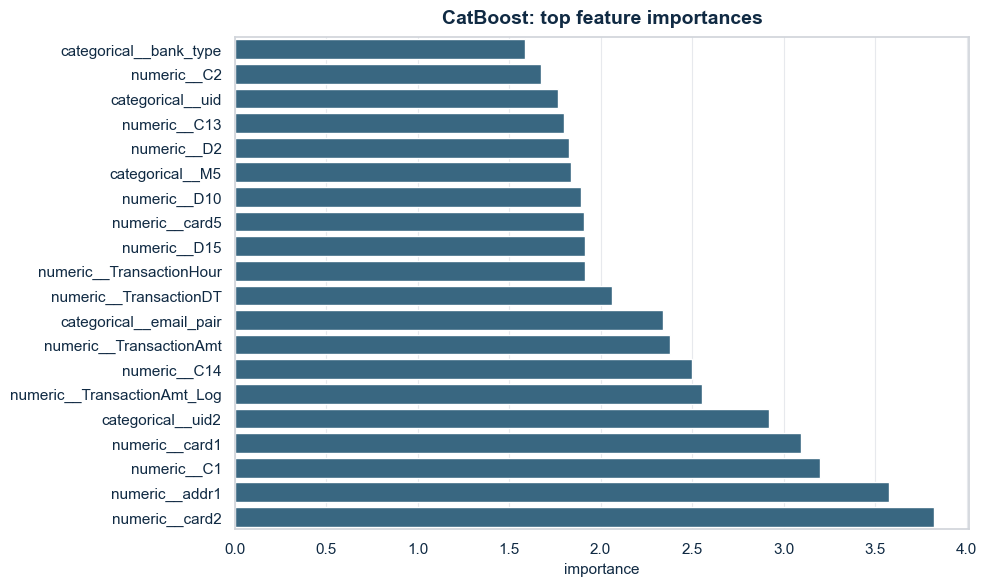

,feature,importance
0,numeric__card2,3.8246
1,numeric__addr1,3.5742
2,numeric__C1,3.2003
3,numeric__card1,3.0969
4,categorical__uid2,2.9214
5,numeric__TransactionAmt_Log,2.5547
6,numeric__C14,2.4980
7,numeric__TransactionAmt,2.3810
8,categorical__email_pair,2.3397
9,numeric__TransactionDT,2.0613


In [8]:
for model_name, importance_frame in benchmark["feature_importances"].items():
    if importance_frame.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(
        data=importance_frame.sort_values("importance", ascending=True),
        x="importance",
        y="feature",
        color=PLOT_COLORS["blue"],
        ax=ax,
    )
    ax.set_title(f"{model_name}: top feature importances")
    ax.set_xlabel("importance")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

    display(importance_frame)


## What Changed From The Baseline

Compared with `02_baseline_logistic_regression.ipynb`, this notebook becomes more competition-oriented in four ways:

- the validation split respects **time order**
- we compare **multiple tree families**, not just one sklearn model
- we add **UID-style and missingness features** inspired by the 1st-place writeup
- we keep the baseline-style diagnostics: metric tables, curves, threshold sweeps, and score distributions

for feature engineering in more detail, open the companion notebook `05_feature_engineering_for_tree_models.ipynb`.
